## Berikut adalah tugas instruksionalmu:

1. Parsing Eksplisit: Ubah kolom waktu_log dari tipe string/object menjadi datetime. Syarat mutlak: Kamu tidak boleh membiarkan Pandas menebak formatnya secara otomatis. Kamu harus menuliskan argumen format=... secara spesifik yang merepresentasikan struktur hari-bulan-tahun_jam:menit tersebut.

2. Manipulasi Indeks: Jadikan kolom yang sudah diubah menjadi datetime tersebut sebagai index dari DataFrame.

3. Filtering Waktu (Tingkat Kesulitan Tambahan): Lakukan slicing pada DataFrame tersebut agar hanya menyisakan data dari tanggal 2 Januari 2026 hingga 3 Januari 2026 saja.

4. Visualisasi: Buat line chart dari data yang sudah di-slice tersebut.
    - Gunakan arsitektur Object-Oriented (fig, ax = plt.subplots()).
    - Berikan marker (penanda titik) pada setiap pergerakan garisnya.
    - Rotasi label tanggal di sumbu X sebesar 45 derajat agar teksnya tidak saling tumpang tindih.

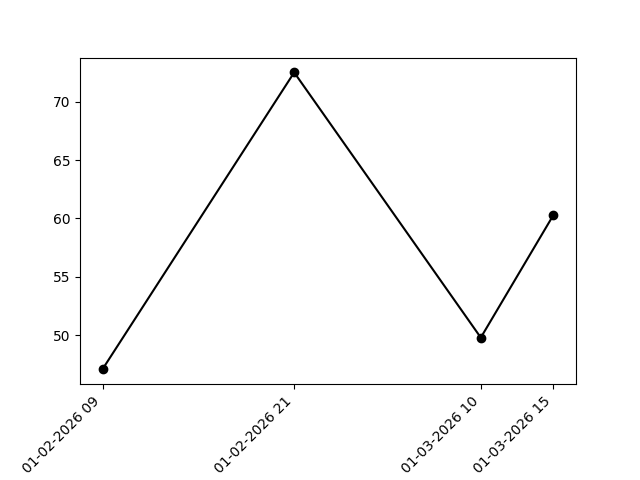

In [20]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Data mentah simulasi suhu server
data_mentah = {
    'waktu_log': ['01-Jan-2026_08:15', '01-Jan-2026_18:30', '02-Jan-2026_09:00', 
                  '02-Jan-2026_21:45', '03-Jan-2026_10:10', '03-Jan-2026_15:00'],
    'suhu_celcius': [45.2, 58.7, 47.1, 72.5, 49.8, 60.3]
}
df = pd.DataFrame(data_mentah)

# Kita Konversi menjadi format waktu
df['waktu_log'] = pd.to_datetime(
    df['waktu_log'],
    format='%d-%b-%Y_%H:%M')

# Kita set kolom menjadi index + rapihkan 
df = df.set_index('waktu_log').sort_index()

# Slicing
df=df.loc['02-Jan-2026':'03-Jan-2026']

# Kolom yang mau di plot
s_celcius = df['suhu_celcius']

fig, ax= plt.subplots()
s_celcius.plot(ax=ax, style='k-', marker='o')

# posisi tick = sesuai data
ax.set_xticks(s_celcius.index)

# format tampilan label
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y %H'))

# rotasi biar kebaca
ax.tick_params(axis='x', rotation=45)

plt.show()

**Perbaikan kode yang lebih skalabel**

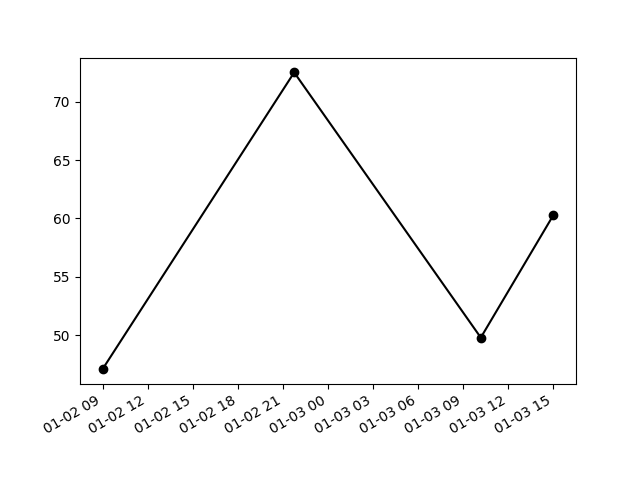

In [17]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt

# Data mentah
data_mentah = {
    'waktu_log': ['01-Jan-2026_08:15', '01-Jan-2026_18:30', '02-Jan-2026_09:00', 
                  '02-Jan-2026_21:45', '03-Jan-2026_10:10', '03-Jan-2026_15:00'],
    'suhu_celcius': [45.2, 58.7, 47.1, 72.5, 49.8, 60.3]
}
df = pd.DataFrame(data_mentah)

# 1. Parsing format explicit
df['waktu_log'] = pd.to_datetime(df['waktu_log'], format='%d-%b-%Y_%H:%M')
df = df.set_index('waktu_log').sort_index()

# 2. Slicing yang Dinamis (Partial String Indexing)
# Ini akan mengambil DARI awal hari 2 Jan HINGGA akhir hari 3 Jan, jam berapapun itu.
df_filtered = df.loc['2026-01-02':'2026-01-03']

# 3. Object-Oriented Plotting
fig, ax = plt.subplots()

# Gunakan fungsi plot asli dari matplotlib pada objek ax
ax.plot(df_filtered.index, df_filtered['suhu_celcius'], color='black', linestyle='-', marker='o')

# 4. Solusi Otomatis untuk Time-Series Formatting
# Fungsi ini otomatis mengatur jarak aman antar tick dan merotasinya agar mudah dibaca, 
# seberapapun padatnya data yang kamu miliki.
fig.autofmt_xdate()

plt.show()